# PSC Robustness Analysis

In [1]:
def default_params(): 
    return {
        'current_model': 'M1', 
        'quantization': 'none', #['none',"int4", "int8", "float32", "float16"]
        'dataset': {
            'path': '/workspaces/CodeSmells/semeru-datasets/code_smells/extraction',
            'transformation_list': ['curated','RenameVariable-1','RenameVariable-2','Add2Equal','SwitchEqualExp','InfixDividing', 'SwitchRelation'],
            'content_column': 'code',
            'sampling_size': 500,
        },
        'alignments_path': '/workspaces/CodeSmells/data/extension/alignments',

        'cache_dir': '/workspaces/CodeSmells/datax/hugging_face_cache',
    }
params = default_params()


#### Imports

In [2]:
import pandas as pd
import os
import time
import numpy as np
from datasets import load_dataset 
from statistics import mean, median
import json
import torch
import gc
import math
from scipy.stats import ks_2samp, wasserstein_distance



In [3]:
import seaborn as sns; sns.set_theme()
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.backends.backend_pdf import PdfPages

In [4]:
from sklearn.preprocessing import StandardScaler
from scipy.stats import boxcox

#### Boostrapping

In [5]:
#| export
def bootstrapping( np_data, np_func, size ):
    """Create a bootstrap sample given data and a function
    For instance, a bootstrap sample of means, or mediands. 
    The bootstrap replicates are a long as the original size
    we can choose any observation more than once (resampling with replacement:np.random.choice)
    """
    
    #Cleaning NaNs
    #np_data_clean = np_data[ np.logical_not( np.isnan(np_data) ) ] 
    
    #The size of the bootstrap replicate is as big as size
    #Creating the boostrap replicates as long as the orignal data size
    #This strategy might work as imputation 
    bootstrap_repl = [ np_func( np.random.choice( np_data, size=len(np_data) ) ) for i in range( size ) ]
    
    #logging.info("Covariate: " + cov) #Empirical Mean
    #logging.info("Empirical Mean: " + str(np.mean(np_data_clean))) #Empirical Mean
    #logging.info("Bootstrapped Mean: " + str( np.mean(bootstrap_repl) ) ) #Bootstrapped Mean
    
    return np.array( bootstrap_repl )

#### Load Aggregates

In [6]:
def get_all_aggregates():
    aggregations = {}
    try:
        for transformation in params['dataset']['transformation_list']:
                transformation_df = pd.read_json(f"{params['alignments_path']}/{params['current_model']}_q_{params['quantization']}/{transformation}/aligned_smells.json")
                transformation_df['transformation'] = transformation
                aggregations[transformation] = transformation_df
    except Exception:
         None
    return aggregations


In [7]:
aggregations = get_all_aggregates()
aggregations['base'] = aggregations.pop('curated')
aggregations['base']['transformation'] = 'base'
aggregations.keys()

dict_keys(['RenameVariable-1', 'RenameVariable-2', 'base'])

In [8]:
aggregations['base']['s_msg_id'].unique()

array(['W0311', 'C0301', 'C0303', 'C0415', 'W0212', 'W0612', 'C0114',
       'W0613', 'C0116', 'C0304', 'C0305', 'C0123', 'C0103', 'W0622',
       'C0209', 'W0511', 'C0321', 'C0200', 'R1705', 'R0914', 'R1735',
       'R0912', 'W1514', 'C2801', 'R1710', 'C0325', 'W0621', 'R1720',
       'R1732', 'W0611', 'W0719', 'W0104', 'W0707', 'W0718', 'R0917',
       'R0913', 'W0102', 'W1309', 'W1406', 'C3001', 'W0601'], dtype=object)

#### Distribution comparisson between transformations

In [9]:
# 3. Define the logit transform
def logit_transform(x, eps=1e-9):
    x_clipped = np.clip(x, eps, 1 - eps)
    return np.log(x_clipped / (1 - x_clipped))

In [10]:
def logit_transform_psc(smell_msg_id, prob_column, decimal_spaces, aggregations):
    filtered_aggregations = {}
    for aggregation_name, aggregation_df in aggregations.items():
        filtered_df = aggregation_df[aggregation_df['s_msg_id'] == smell_msg_id].copy()
        ## outliers removal
        # Calculate Q1 (25th percentile) and Q3 (75th percentile)
        Q1 = filtered_df[prob_column].quantile(0.25)
        Q3 = filtered_df[prob_column].quantile(0.75)

        # Compute the Interquartile Range (IQR)
        IQR = Q3 - Q1

        # Define lower and upper bounds for outliers
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter out the outliers
        filtered_df = filtered_df[(filtered_df[prob_column] >= lower_bound) & 
              (filtered_df[prob_column] <= upper_bound)]
        #round
        filtered_df[prob_column] = filtered_df[prob_column].round(decimal_spaces)

        filtered_df[prob_column+'_trans'] = logit_transform(filtered_df[prob_column])
        filtered_aggregations[aggregation_name] = filtered_df
    return filtered_aggregations

In [81]:
def plot_density_distributions(smell_msg_id, psc_column, filtered_aggregations, plot_stat= 'density', log_scale =False):
    combined_aggregates = pd.concat(filtered_aggregations.values(), ignore_index=True)
    # Plot histogram of actual data
    plt.figure(figsize=(10, 6))
    # Plot without the extra label parameter
    ax = sns.histplot(x=psc_column, 
                  data=combined_aggregates, 
                  hue='transformation', 
                  kde=True, 
                  bins=500, 
                  stat=plot_stat, alpha= 0.3)

    # Set y-axis to log scale
    if log_scale: ax.set_yscale("log")
    
    # Add labels and title
    plt.title("Distribution by Transformation")
    plt.xlabel("PSC (Propensity Smelly Score)")

    # Show the plot
    plt.show()


In [47]:
def compute_cliff_delta(distribution_1, distribution_2):
    n1, n2 = len(distribution_1), len(distribution_2)
    greater = sum(x > y for x in distribution_1 for y in distribution_2)
    lesser = sum(x < y for x in distribution_1 for y in distribution_2)
    return (greater - lesser) / (n1 * n2)

In [48]:
def bootstrap_ks(distribution_1, distribution_2, n_boot=1000):
    n1, n2 = len(distribution_1), len(distribution_2)
    D_boot = [ks_2samp(np.random.choice(distribution_1, size=n1, replace=True),
                        np.random.choice(distribution_2, size=n2, replace=True))[0] 
              for _ in range(n_boot)]
    return np.percentile(D_boot, [2.5, 97.5])

In [49]:
def compare_distributions(distribution_1, distribution_2):
    np.random.seed(0)

    # Make distributions the same size
    min_size = min(len(distribution_1), len(distribution_2))
    distribution_1 = np.random.choice(distribution_1, size=min_size, replace=False)
    distribution_2 = np.random.choice(distribution_2, size=min_size, replace=False)

    # Determine n_boot dynamically
    n_boot = max(100, min(1000, min_size // 10))
    
    ks_statistic, p_value = ks_2samp(distribution_1, distribution_2, alternative='two-sided')
    st_effect_size = ks_statistic * math.sqrt((min_size * min_size) / (min_size + min_size))
    cliff_delta = compute_cliff_delta(distribution_1, distribution_2)
    wasserstein_dist = wasserstein_distance(distribution_1, distribution_2)
    ci_ks_lower, ci_ks_upper = bootstrap_ks(distribution_1, distribution_2, n_boot)

    # Final decision based on all computed values
    practically_equivalent = (ci_ks_upper < 0.21) and (abs(cliff_delta) < 0.147) and (p_value > 0.05) and (wasserstein_dist < 0.1)
    
    return {
        "ks_stat": ks_statistic,
        "ci_ks_stat": (ci_ks_lower, ci_ks_upper),
        "p_value": p_value,
        "st_effect_size": st_effect_size,
        "cliffs_delta": cliff_delta,
        "wasserstein_dist" : wasserstein_dist,
        "equivalence": practically_equivalent
    }

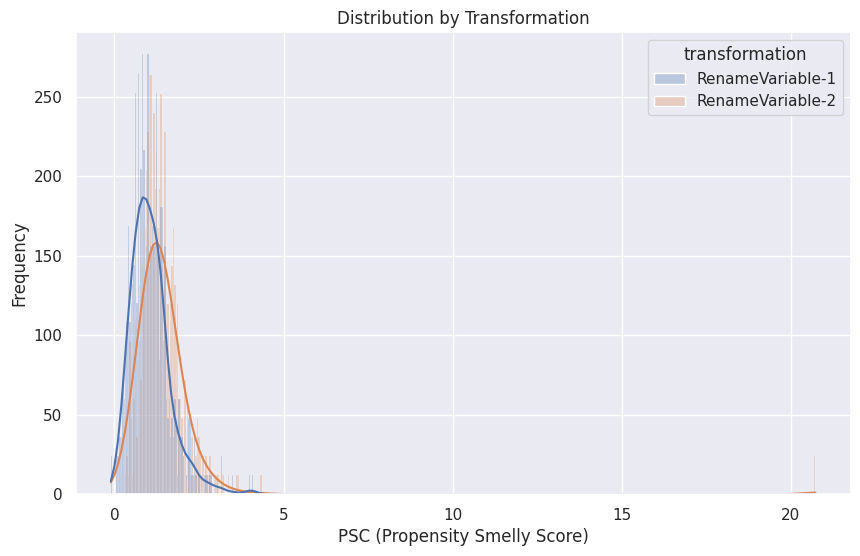

In [90]:
##probability distributions per type of smell
smell_msg_id = 'R1705'
prob_column = 'code_smell_psc_relative'
#aggregations.pop('base')
filtered_aggregations = logit_transform_psc(smell_msg_id, prob_column, 4, aggregations)
plot_density_distributions(smell_msg_id, prob_column+'_trans', filtered_aggregations, 'frequency')
#plot_density_distributions(smell_msg_id, prob_column, aggregations)

In [88]:
compare_distributions(filtered_aggregations['RenameVariable-1'][prob_column], filtered_aggregations['RenameVariable-2'][prob_column])

{'ks_stat': 0.2738336713995943,
 'ci_ks_stat': (0.2402129817444219, 0.33073022312373224),
 'p_value': 1.138220176732223e-16,
 'st_effect_size': 4.299275848264753,
 'cliffs_delta': -0.3397010479368358,
 'wasserstein_dist': 0.0545868154158215,
 'equivalence': False}

### Variability

In [86]:
## variability (std)
alignments_df = aggregations['RenameVariable-1']
alignments_df.groupby('s_msg_id')['code_smell_psc_relative'].describe().sort_values(by='std', ascending=True)

,count,mean,std,min,25%,50%,75%,max
s_msg_id,,,,,,,,
C0116,500.0,0.002517,0.002470,0.000714,0.001209,0.001272,0.002590,0.013916
R1710,500.0,0.004121,0.003620,0.000714,0.001237,0.002590,0.009806,0.009905
R0914,3.0,0.004568,0.004673,0.001209,0.001900,0.002590,0.006247,0.009904
R0913,500.0,0.005809,0.004869,0.000721,0.001499,0.003032,0.009905,0.032403
R0917,500.0,0.005919,0.007421,0.000721,0.001467,0.003032,0.009904,0.133854
W0102,497.0,0.013768,0.012017,0.000792,0.003032,0.009806,0.032403,0.032404
R0912,500.0,0.007042,0.016659,0.000721,0.001471,0.002590,0.009905,0.133856
R1720,500.0,0.731109,0.092746,0.266906,0.672681,0.735869,0.793863,1.000000
R1705,499.0,0.729838,0.098079,0.423749,0.660440,0.730892,0.796084,1.000000
